In [ ]:
import pandas as pd
import numpy as np

this works now


In [3]:
%pip install yfinance matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of yfinance to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 32.1 MB/s  0:00:00
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15635 sha256=4447b77721680548bcdd4732aef931fde72e425c764a246739583ab4c53ced14
  Stored in directory: /Users/gustavo/Library/Caches/pip/wheels/98/75/bc/9eaa3cdeaaca347bab26c7e83a7e2f365d82584d65a2d48e7a
Successfully built multitasking
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [yfinance]/16 [cffi]buf]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import yfinance as yf
import matplotlib.pyplot as plt

/Users/gustavo/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [6]:
#downloading apple data and S&P 500

apple = yf.download("AAPL", start = '2025-01-01')
spy = yf.download('SPY', start = '2025-01-01')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [7]:
apple.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-02,242.525177,247.746654,240.506207,247.577564,55740700
2025-01-03,242.037827,242.853364,240.575812,242.037827,40244100
2025-01-06,243.668915,245.986258,241.878691,242.982661,45045600
2025-01-07,240.894058,244.215908,240.038730,241.659864,40856000
2025-01-08,241.381393,242.385916,238.745797,240.605632,37628900


In [13]:
#calculates the returns of the stocks (percent change)
apple['Daily Return'] = apple["Close"].pct_change()
spy['Daily Return'] = spy["Close"].pct_change()

#calculate volatility (risk = std)

apple_vol = apple['Daily Return'].std() * (252**0.5) #252 trading days in one year square rooted
spy_vol = spy['Daily Return'].std() * (252**0.5)

print(f"Apple Annualized Volatility : {apple_vol:.2%}")
print(f"S&P 500 Annualized Volatility : {spy_vol:.2%}")



Apple Annualized Volatility : 30.82%
S&P 500 Annualized Volatility : 18.52%


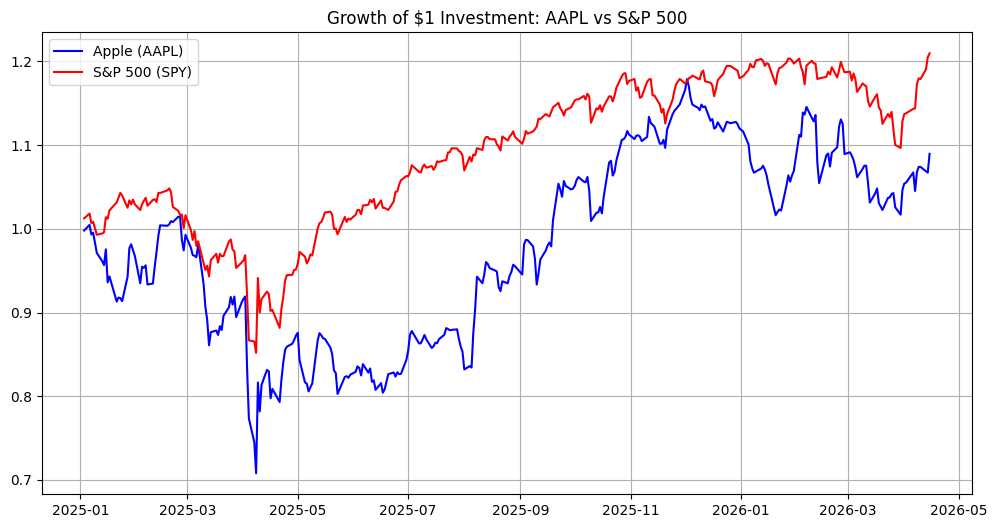

In [15]:
# calculate the growth of $1 investment
apple_growth = (1+apple['Daily Return']).cumprod()
spy_growth = (1+spy['Daily Return']).cumprod()

#plot the graph to visualize change

plt.figure(figsize= (12,6))
plt.plot(apple_growth,label="Apple (AAPL)", color= 'blue')
plt.plot(spy_growth,label="S&P 500 (SPY)", color= 'red')

plt.title ("Growth of $1 Investment: AAPL vs S&P 500")
plt.legend()
plt.grid(True)
plt.show()